# NHANES Age Group Classification
### Summer Analytics 2026 Hackathon

## Problem Statement

The objective of this project is to build a machine learning model capable of predicting whether an individual belongs to the **Adult (0)** or **Senior (1)** age group using health, lifestyle, and laboratory measurements from the NHANES dataset.

This is a **binary classification** problem where:

- **Adult = 0**
- **Senior = 1**

The final model will be trained on the provided training dataset and used to generate predictions for the unseen test dataset.

---

# Project Workflow

The project follows a complete end-to-end Machine Learning pipeline.

## Phase 1 — Setup & Data Loading

- Import required libraries
- Load train and test datasets
- Display dataset overview
- Verify feature consistency

---

## Phase 2 — Exploratory Data Analysis (EDA)

### 2.1 Dataset Overview

- Dataset dimensions
- Data types
- Summary statistics
- Duplicate records

### 2.2 Missing Value Analysis

- Missing value count
- Missing value percentage
- Missing value visualization

### 2.3 Target Variable Analysis

- Class distribution
- Class imbalance visualization

### 2.4 Univariate Analysis

Understand each feature individually.

- Histograms
- KDE plots
- Count plots
- Boxplots

### 2.5 Bivariate Analysis

Study relationships between predictors and target.

- Feature vs Target
- Category comparisons
- Distribution by age group

### 2.6 Correlation Analysis

- Correlation matrix
- Heatmap
- Multicollinearity inspection

### 2.7 Key EDA Insights

Summarize important findings that will guide preprocessing and feature engineering.

---

## Phase 3 — Data Preprocessing

### 3.1 Data Cleaning

- Remove unnecessary columns
- Drop identifier (SEQN)

### 3.2 Target Preparation

- Verify target labels
- Encode Adult → 0
- Encode Senior → 1

### 3.3 Missing Value Treatment

Missing values will be handled based on insights obtained during EDA.

Possible strategies include:

- Median Imputation
- Mode Imputation
- Missing Indicators

### 3.4 Outlier Treatment

Investigate and treat extreme observations using suitable statistical techniques where appropriate.

---

## Phase 4 — Feature Engineering

Generate meaningful predictors to improve model performance.

Possible engineered features include:

- BMI Categories
- High Glucose Indicator
- High Insulin Indicator
- Diabetes Risk Indicator
- Glucose-to-Insulin Ratio
- BMI × Glucose Interaction
- Physical Activity Risk Score

Feature importance techniques will also be used to retain the most informative variables.

---

## Phase 5 — Class Imbalance Handling

- Visualize class distribution
- Evaluate imbalance severity
- Apply:
    - Class Weights
    - SMOTE (if appropriate)
- Compare model performance before and after balancing

---

## Phase 6 — Model Development

Build multiple machine learning models.

### Baseline Model

- Logistic Regression

### Tree-Based Models

- Decision Tree
- Random Forest
- Extra Trees

### Boosting Models

- XGBoost
- LightGBM
- CatBoost

Each model will be evaluated using identical validation procedures.

---

## Phase 7 — Cross Validation & Hyperparameter Optimization

Improve model generalization through:

- Stratified K-Fold Cross Validation
- Grid Search
- Random Search
- Bayesian Optimization (if applicable)

---

## Phase 8 — Model Evaluation

Models will be compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

Feature importance will also be analyzed.

The best-performing model will be selected as the final model.

---

## Phase 9 — Test Prediction & Submission

- Predict labels for the test dataset
- Generate submission file
- Verify submission format
- Export:

submission.csv

where

- Adult = 0
- Senior = 1

---

# Goal

The goal is not only to achieve high predictive performance but also to produce a clean, reproducible, and well-documented machine learning workflow emphasizing thoughtful Exploratory Data Analysis (EDA), robust Feature Engineering, and careful Model Selection.

# Phase 1

In [130]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: '%.3f' % x)
sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

print("✅ Done Loading")

✅ Done Loading


In [131]:
# Loading datasets

train = pd.read_csv("Train_dataset.csv")
test = pd.read_csv("Test_dataset.csv")
sample = pd.read_csv("Sample_submission.csv")

In [132]:
# Shape of the datasets 
print("Training Shape :", train.shape)
print("Testing Shape  :", test.shape)
print("Sample Shape   :", sample.shape)

Training Shape : (1966, 9)
Testing Shape  : (312, 8)
Sample Shape   : (312, 1)


In [133]:
train.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.000,2.000,2.000,35.700,110.000,2.000,150.000,14.910,Adult
1,73568.000,2.000,2.000,20.300,89.000,2.000,80.000,3.850,Adult
2,73576.000,1.000,2.000,23.200,89.000,2.000,68.000,6.140,Adult
3,73577.000,1.000,2.000,28.900,104.000,NaN,84.000,16.150,Adult
4,73580.000,2.000,1.000,35.900,103.000,2.000,81.000,10.920,Adult


In [134]:
test.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
0,77017.000,1.000,1.000,32.200,96.000,2.000,135.000,15.110
1,75580.000,2.000,2.000,26.300,100.000,2.000,141.000,15.260
2,73820.000,1.000,2.000,28.600,107.000,2.000,136.000,8.820
3,80489.000,2.000,1.000,22.100,93.000,2.000,111.000,12.130
4,82047.000,1.000,1.000,24.700,91.000,2.000,105.000,3.120


In [135]:
# Columns of the dataset
train.columns.tolist()

['SEQN',
 'RIAGENDR',
 'PAQ605',
 'BMXBMI',
 'LBXGLU',
 'DIQ010',
 'LBXGLT',
 'LBXIN',
 'age_group']

In [136]:
# Dataset oveview
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1966 entries, 0 to 1965
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       1954 non-null   float64
 1   RIAGENDR   1948 non-null   float64
 2   PAQ605     1953 non-null   float64
 3   BMXBMI     1948 non-null   float64
 4   LBXGLU     1953 non-null   float64
 5   DIQ010     1948 non-null   float64
 6   LBXGLT     1955 non-null   float64
 7   LBXIN      1957 non-null   float64
 8   age_group  1952 non-null   object 
dtypes: float64(8), object(1)
memory usage: 138.4+ KB


In [137]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SEQN,1954.000,NaN,NaN,NaN,78683.622,2924.116,73564.000,76194.000,78717.000,81217.000,83727.000
RIAGENDR,1948.000,NaN,NaN,NaN,1.510,0.500,1.000,1.000,2.000,2.000,2.000
PAQ605,1953.000,NaN,NaN,NaN,1.825,0.399,1.000,2.000,2.000,2.000,7.000
BMXBMI,1948.000,NaN,NaN,NaN,27.965,7.328,14.500,22.800,26.800,31.300,70.100
LBXGLU,1953.000,NaN,NaN,NaN,99.491,16.775,63.000,91.000,97.000,104.000,405.000
DIQ010,1948.000,NaN,NaN,NaN,2.016,0.188,1.000,2.000,2.000,2.000,3.000
LBXGLT,1955.000,NaN,NaN,NaN,115.150,46.272,40.000,87.000,105.000,131.000,604.000
LBXIN,1957.000,NaN,NaN,NaN,11.863,9.757,0.140,5.800,9.030,14.480,102.290
age_group,1952,2,Adult,1638,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Phase 2

### Data Structure

In [138]:
# Data structure

print("="*50)
print("Training Dataset")
print("="*50)

print(f"Rows    : {train.shape[0]}")
print(f"Columns : {train.shape[1]}")

print("\n")

train.info()

print("\n")

print("="*50)
print("Testing Dataset")
print("="*50)

print(f"Rows    : {test.shape[0]}")
print(f"Columns : {test.shape[1]}")

print("\n")

test.info()

Training Dataset
Rows    : 1966
Columns : 9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1966 entries, 0 to 1965
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       1954 non-null   float64
 1   RIAGENDR   1948 non-null   float64
 2   PAQ605     1953 non-null   float64
 3   BMXBMI     1948 non-null   float64
 4   LBXGLU     1953 non-null   float64
 5   DIQ010     1948 non-null   float64
 6   LBXGLT     1955 non-null   float64
 7   LBXIN      1957 non-null   float64
 8   age_group  1952 non-null   object 
dtypes: float64(8), object(1)
memory usage: 138.4+ KB


Testing Dataset
Rows    : 312
Columns : 8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      310 non-null    float64
 1   RIAGENDR  310 non-null    float64
 2   PAQ605    311 non-null    float64
 3   BMXB

### Missing Value Analysis

In [139]:
# Sum of missing data
print(f"Train missing data sum:{train.isna().sum().sum()}")
print(f"Test missing data sum:{test.isna().sum().sum()}")

Train missing data sum:126
Test missing data sum:11


In [140]:
# Train dataset
missing = train.isnull().sum()

missing_percent = (
    train.isnull()
         .mean()
         .mul(100)
         .sort_values(ascending=False)
)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})
print("\n Train Dataset")
print(missing_df)



# Test Dataset
missing_test = test.isnull().sum()

missing_percent_test = (
    test.isnull()
         .mean()
         .mul(100)
         .sort_values(ascending=False)
)

missing_df_test = pd.DataFrame({
    "Missing Values": missing_test,
    "Percentage": missing_percent_test
})
print("\n Test Dataset")
print(missing_df_test)


 Train Dataset
           Missing Values  Percentage
BMXBMI                 18       0.916
DIQ010                 18       0.916
LBXGLT                 11       0.560
LBXGLU                 13       0.661
LBXIN                   9       0.458
PAQ605                 13       0.661
RIAGENDR               18       0.916
SEQN                   12       0.610
age_group              14       0.712

 Test Dataset
          Missing Values  Percentage
BMXBMI                 1       0.321
DIQ010                 1       0.321
LBXGLT                 2       0.641
LBXGLU                 1       0.321
LBXIN                  1       0.321
PAQ605                 1       0.321
RIAGENDR               2       0.641
SEQN                   2       0.641


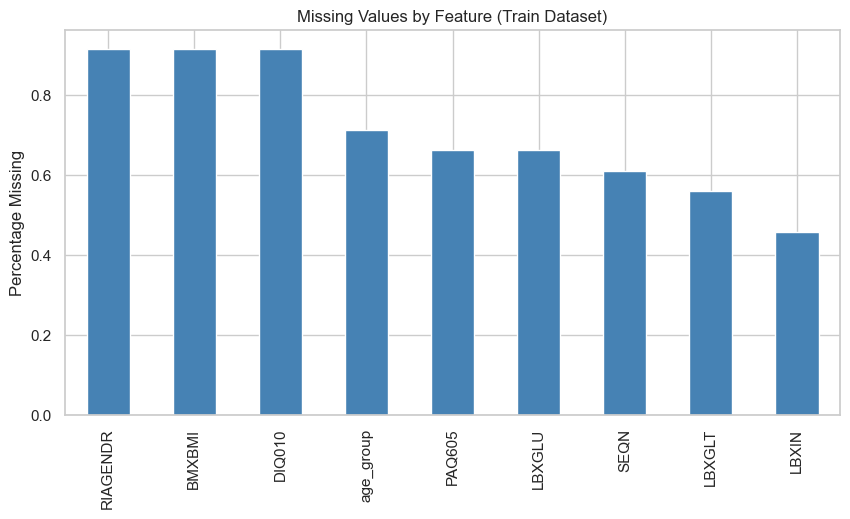

In [141]:
# Missing Value Visualisation for train dataset

missing_percent.plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel("Percentage Missing")
plt.title("Missing Values by Feature (Train Dataset)")
plt.show()

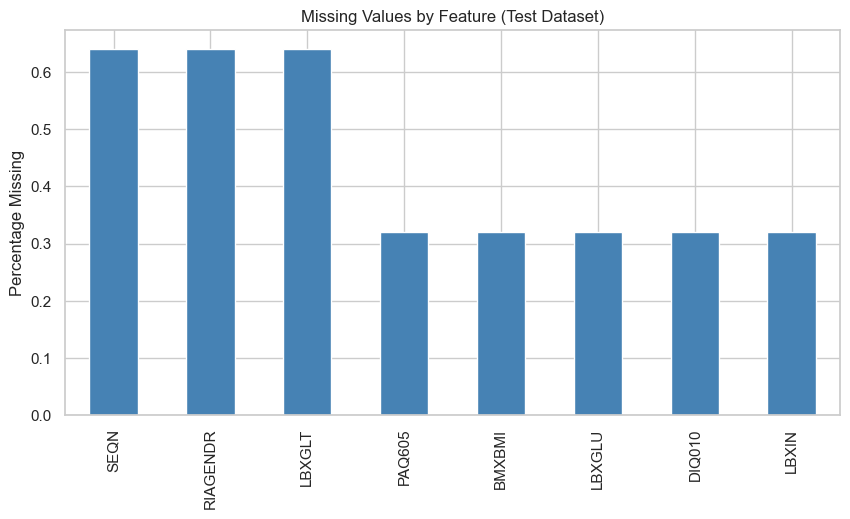

In [142]:
# Missing Value Visualisation for test dataset

missing_percent_test.plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel("Percentage Missing")
plt.title("Missing Values by Feature (Test Dataset)")
plt.show()

## Target Variable Distribution (Class Imbalance)

In [143]:
# Target Variable Distribution
# Understanding the distribution of the target variable is important because highly imbalanced classes may require specialized techniques such as class weighting or oversampling.


# --- Target Distribution ---

target_counts = train['age_group'].value_counts()
target_pct = train['age_group'].value_counts(normalize=True) * 100

print("=== Target Class Distribution ===")
print(pd.DataFrame({
    'Count': target_counts,
    'Percentage %': target_pct.round(2)
}))


=== Target Class Distribution ===
           Count  Percentage %
age_group                     
Adult       1638        83.910
Senior       314        16.090


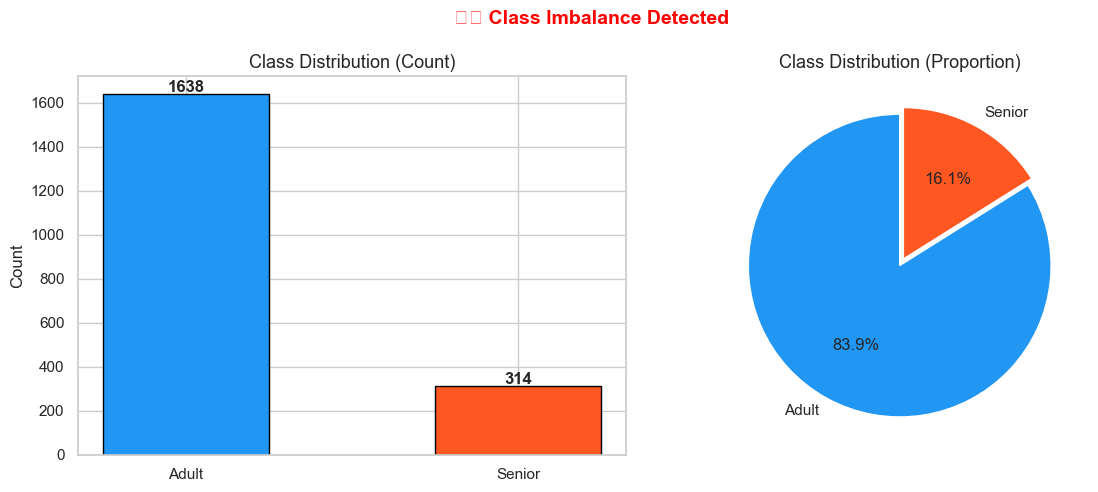


⚠️  Imbalance Ratio: 1 Senior for every 5.2 Adults
→ I  will address this in Phase 5 using SMOTE or class weights


In [144]:
#  Visualizing Class Imbalance 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['Adult', 'Senior'], target_counts.values, 
            color=['#2196F3', '#FF5722'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Adult', 'Senior'],
            autopct='%1.1f%%', colors=['#2196F3', '#FF5722'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)

plt.suptitle('⚠️ Class Imbalance Detected', fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.show()

print(f"\n⚠️  Imbalance Ratio: 1 Senior for every {round(target_counts['Adult']/target_counts['Senior'], 1)} Adults")
print("→ I  will address this in Phase 5 using SMOTE or class weights")

##  Feature Distributions

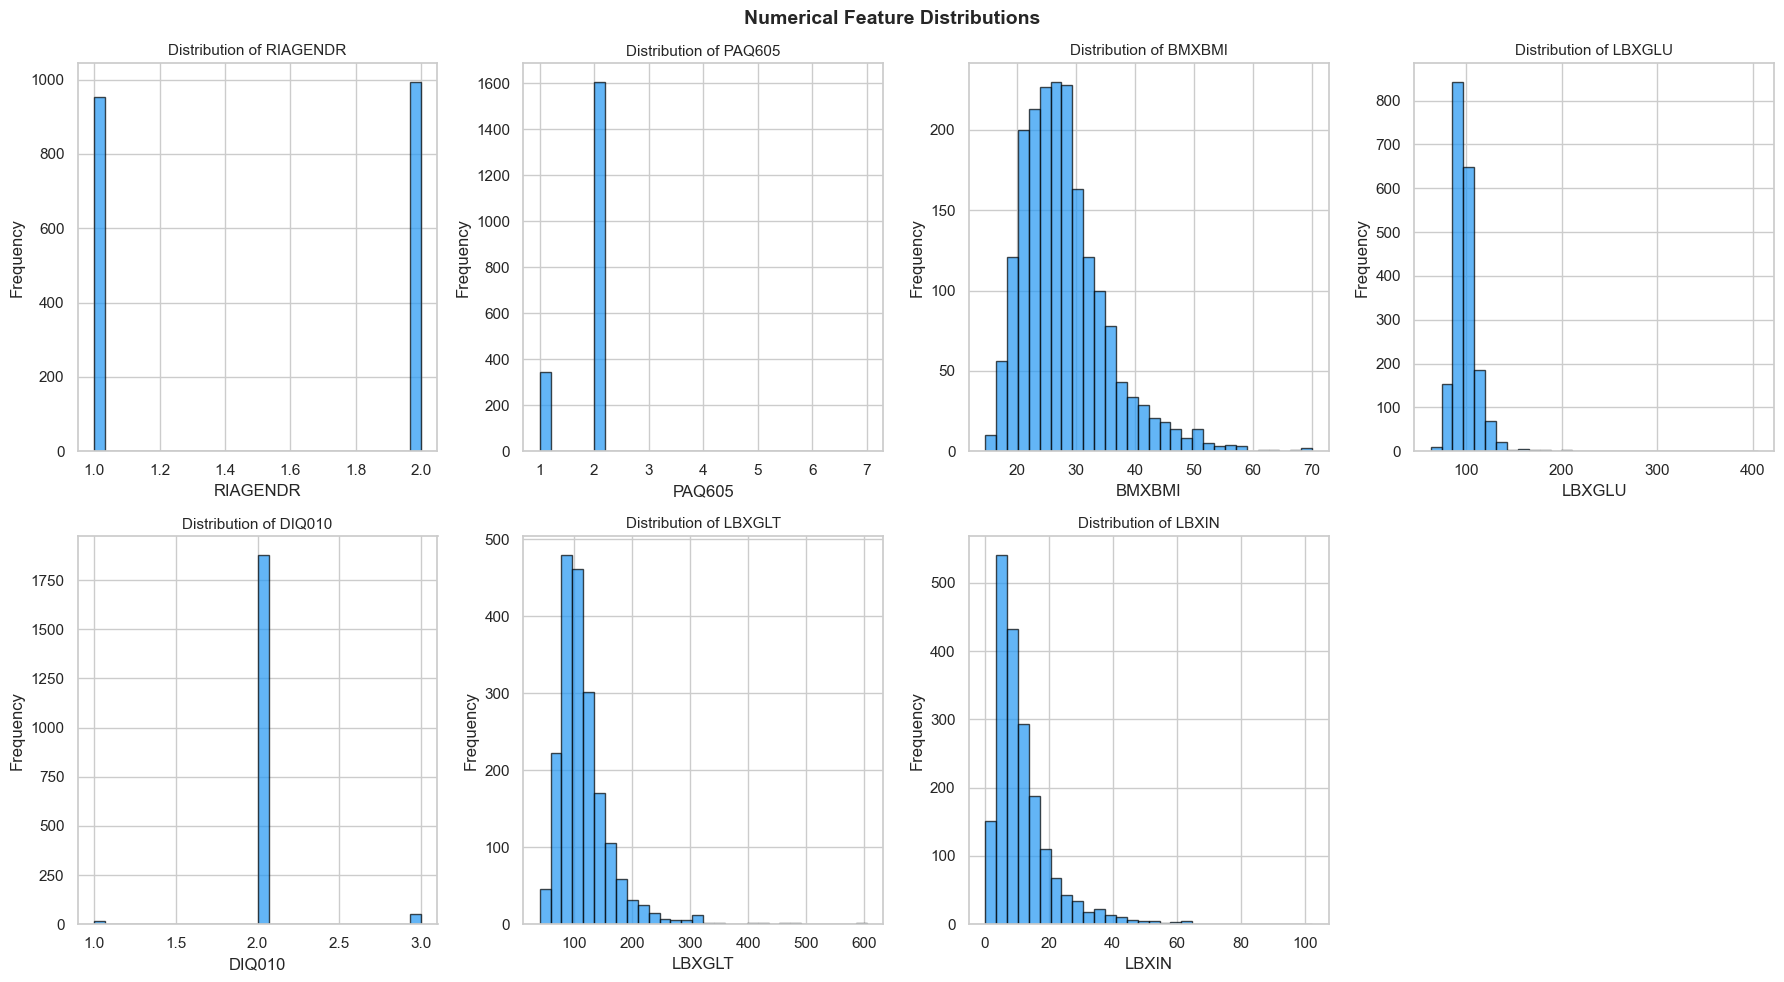

In [145]:
# I examine the distribution of numerical variables to understand their central tendency, spread, skewness, and potential outliers.

# Distribution of Each Feature

Numerical_features = ['RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(Numerical_features):
    axes[i].hist(train[col].dropna(), bins=30, color='#2196F3', 
                 edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)  # hide last empty subplot
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

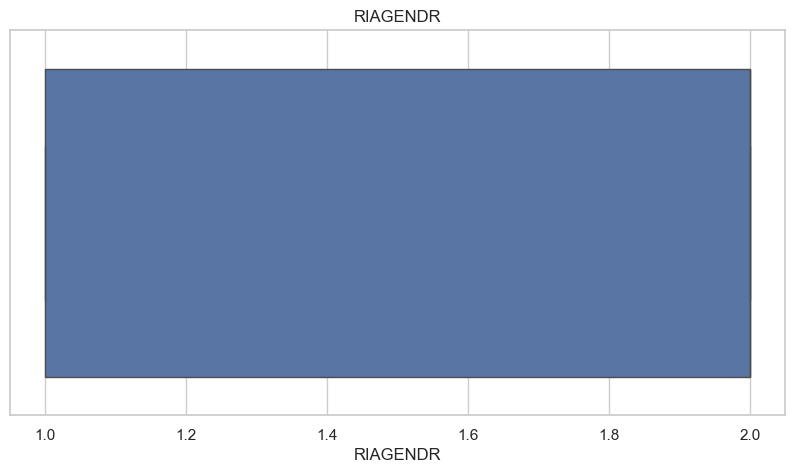

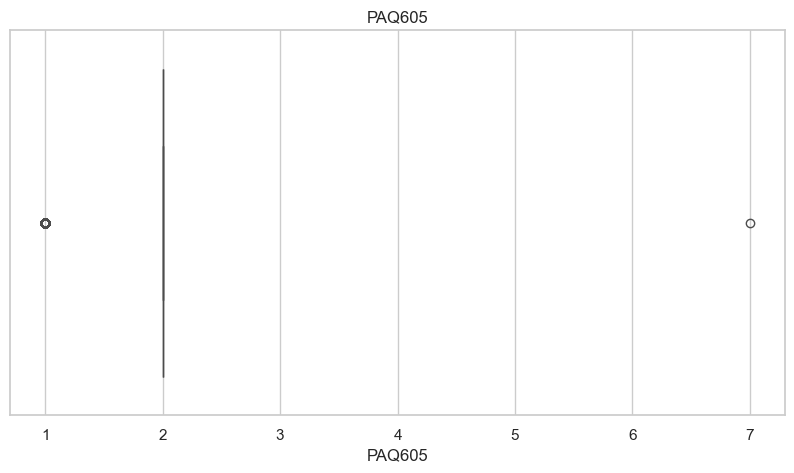

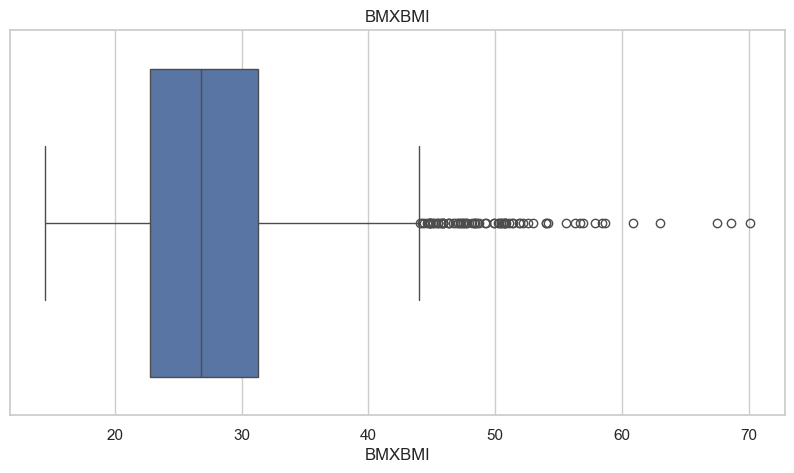

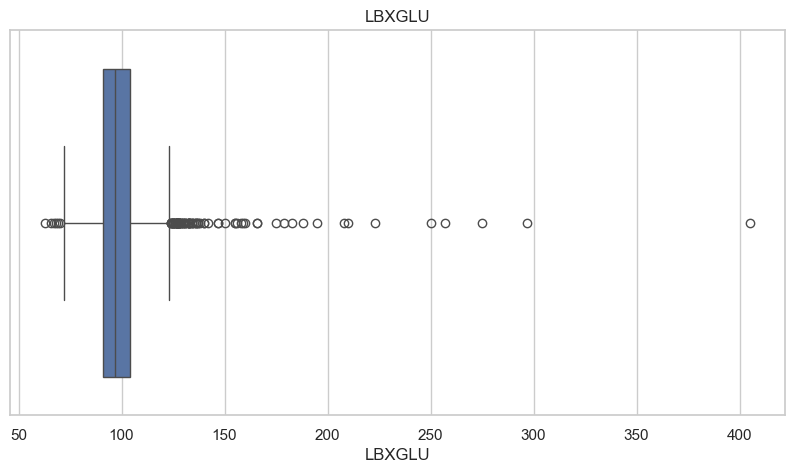

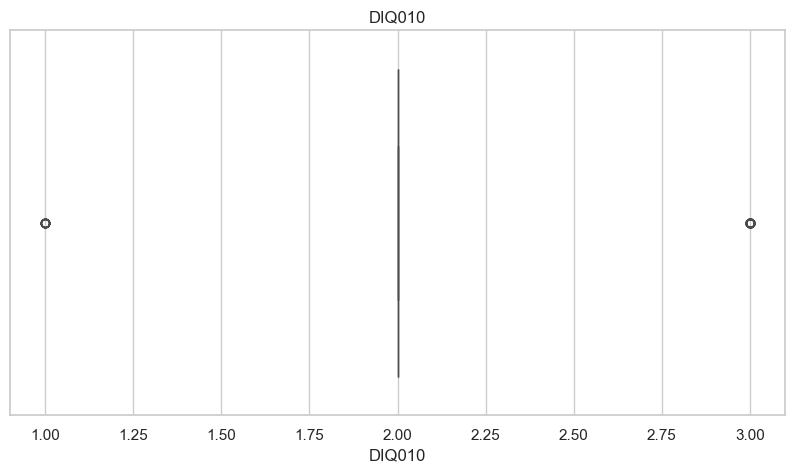

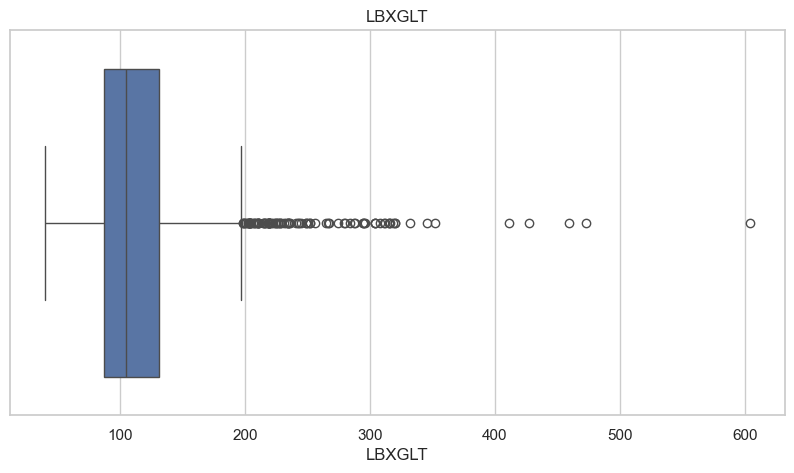

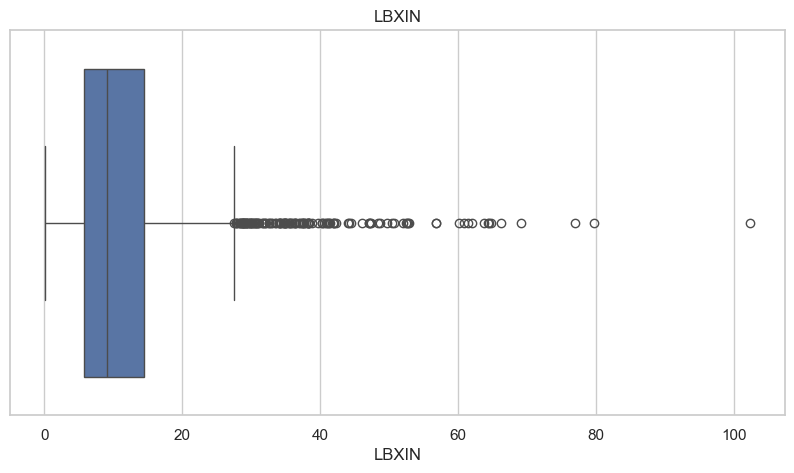

In [146]:
# Boxplot 
for feature in Numerical_features:
    
    sns.boxplot(
        x=train[feature]
    )

    plt.title(feature)

    plt.show()

#### Observation: The histograms provide insight into the shape of each distribution, while the boxplots help identify potential outliers that may require treatment during preprocessing.

## Correlation Analysis

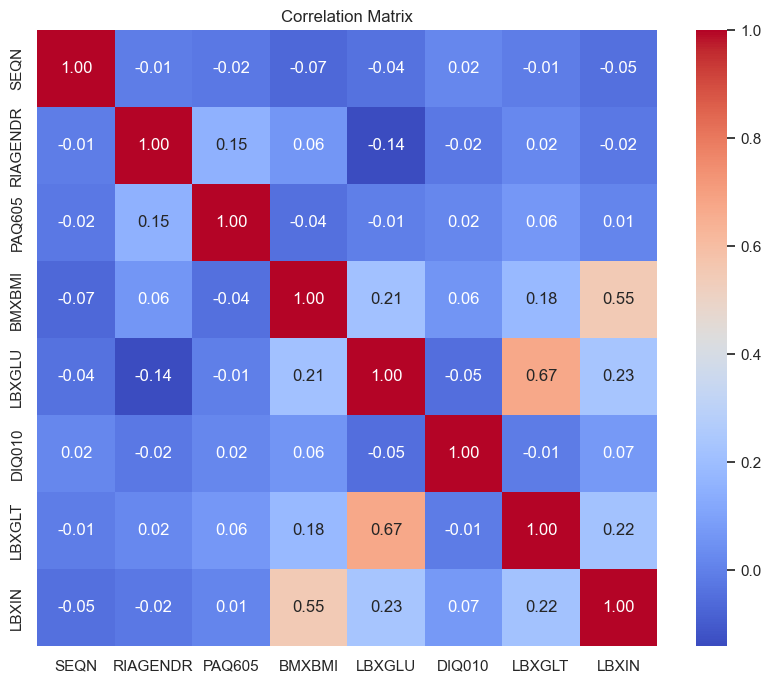

In [147]:
plt.figure(figsize=(10,8))

corr = train.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Feature vs Target Analysis

### Numerical vs Target

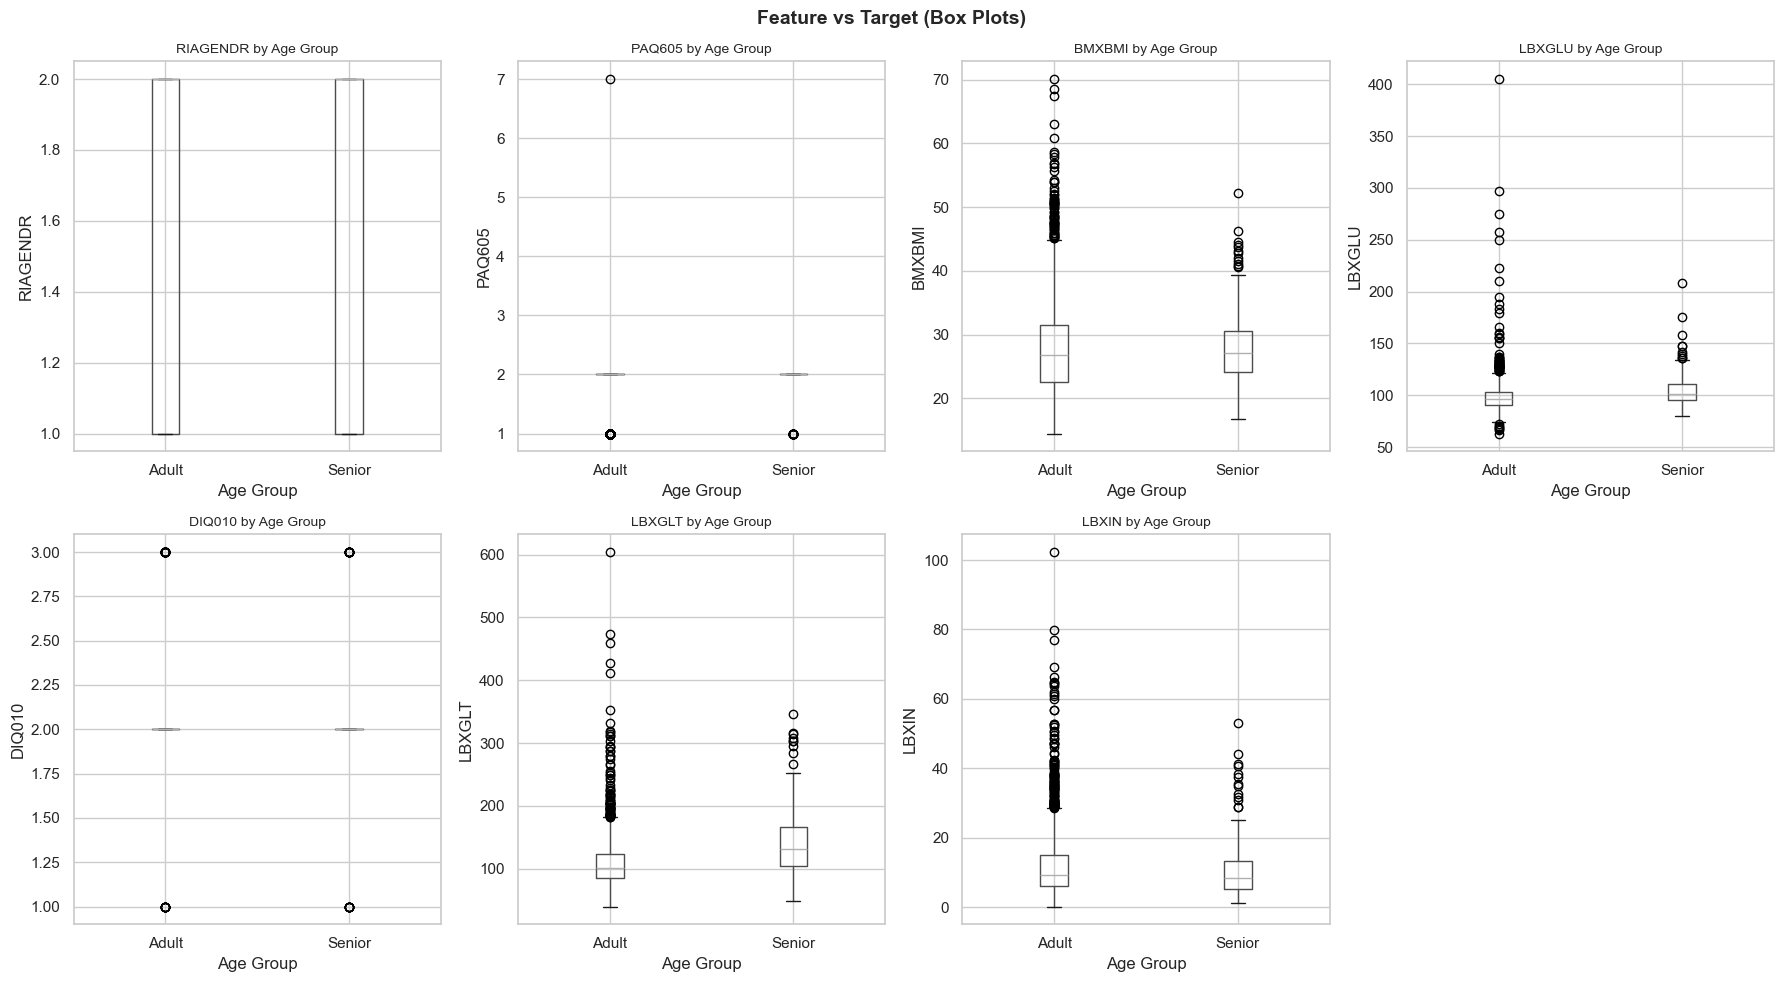

In [148]:
# Encoding target temporarily for analysis 

train['age_group_enc'] = train['age_group'].map({'Adult': 0, 'Senior': 1})

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(Numerical_features):
    train.boxplot(column=col, by='age_group', ax=axes[i])
    axes[i].set_title(f'{col} by Age Group', fontsize=10)
    axes[i].set_xlabel('Age Group')
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)
plt.suptitle('Feature vs Target (Box Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [149]:
# Mean feature values by class

print("=== Mean Feature Values by Age Group ===")
train.groupby('age_group')[Numerical_features].mean().T

=== Mean Feature Values by Age Group ===


age_group,Adult,Senior
RIAGENDR,1.509,1.510
PAQ605,1.809,1.910
BMXBMI,28.019,27.784
LBXGLU,98.527,104.400
DIQ010,2.014,2.026
LBXGLT,110.015,141.361
LBXIN,12.154,10.416


## EDA CONCLUSION
### LBXGLU (glucose) and DIQ010 (Diabetes) show the strongest  separation between Adults and Seniors.
### RIAGENDR, PAQ605, and LBXIN show very little discriminative power on their own.
### Feature engineering will focus on glucose and diabetes-related interactions

# Phase 3

### Data Preprocessing

In [150]:


# Droping ID column (SEQN is just an identifier, not a feature) 

train = train.drop(columns=['SEQN'])
test_ids = test['SEQN'].copy()  # save for submission later
test = test.drop(columns=['SEQN'])

print("✅ SEQN dropped")
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

✅ SEQN dropped
Train shape: (1966, 9)
Test shape:  (312, 7)


In [151]:
# Droping rows where target is missing 

before = len(train)
train = train.dropna(subset=['age_group'])
after = len(train)

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Rows dropped: {before - after}")

Rows before: 1966
Rows after:  1952
Rows dropped: 14


In [152]:
# Encoding target (Adult=0, Senior=1)

train['age_group'] = train['age_group'].map({'Adult': 0, 'Senior': 1})

print("✅ Target encoded")
print(train['age_group'].value_counts())
print()

# Also droping the temporary encoded column from EDA if it exists
if 'age_group_enc' in train.columns:
    train = train.drop(columns=['age_group_enc'])
    print("✅ Temp EDA column dropped")

✅ Target encoded
age_group
0    1638
1     314
Name: count, dtype: int64

✅ Temp EDA column dropped


In [153]:



# Separate features and target
X_train = train.drop(columns=['age_group'])
y_train = train['age_group']
X_test = test.copy()

# Define column types properly
categorical_cols = ['RIAGENDR', 'PAQ605', 'DIQ010']
continuous_cols  = ['BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN']

# --- Impute categorical with MODE ---
for col in categorical_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col]  = X_test[col].fillna(mode_val)
    X_train[col] = X_train[col].astype(int)
    X_test[col]  = X_test[col].astype(int)
    print(f"✅ {col} | Mode imputed: {mode_val} | Unique: {sorted(X_train[col].unique())}")

print()

# --- Impute continuous with MEDIAN (all skewed > 1) ---
from sklearn.impute import SimpleImputer
median_imputer = SimpleImputer(strategy='median')
X_train[continuous_cols] = median_imputer.fit_transform(X_train[continuous_cols])
X_test[continuous_cols]  = median_imputer.transform(X_test[continuous_cols])
print(f"✅ Continuous cols median imputed")

print()
print(f"Missing in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing in X_test:  {X_test.isnull().sum().sum()}")

✅ RIAGENDR | Mode imputed: 2.0 | Unique: [np.int64(1), np.int64(2)]
✅ PAQ605 | Mode imputed: 2.0 | Unique: [np.int64(1), np.int64(2), np.int64(7)]
✅ DIQ010 | Mode imputed: 2.0 | Unique: [np.int64(1), np.int64(2), np.int64(3)]

✅ Continuous cols median imputed

Missing in X_train: 0
Missing in X_test:  0


In [154]:
# ApplyING Imputation 

from sklearn.impute import SimpleImputer

# Separating features
X_train = train.drop(columns=['age_group'])
y_train = train['age_group']
X_test = test.copy()

# Identifying skewed vs symmetric columns
skewed_cols = []
mean_cols = []

for col in Numerical_features:
    if abs(X_train[col].skew()) > 1:
        skewed_cols.append(col)
    else:
        mean_cols.append(col)

print(f"Median imputation: {skewed_cols}")
print(f"Mean imputation:   {mean_cols}")

# Applying median imputer
if skewed_cols:
    median_imputer = SimpleImputer(strategy='median')
    X_train[skewed_cols] = median_imputer.fit_transform(X_train[skewed_cols])
    X_test[skewed_cols] = median_imputer.transform(X_test[skewed_cols])

# Applying mean imputer
if mean_cols:
    mean_imputer = SimpleImputer(strategy='mean')
    X_train[mean_cols] = mean_imputer.fit_transform(X_train[mean_cols])
    X_test[mean_cols] = mean_imputer.transform(X_test[mean_cols])

print()
print("✅ Imputation done")
print(f"Missing in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing in X_test:  {X_test.isnull().sum().sum()}")

Median imputation: ['BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN']
Mean imputation:   ['RIAGENDR', 'PAQ605']

✅ Imputation done
Missing in X_train: 0
Missing in X_test:  0


### Outlier Investigation

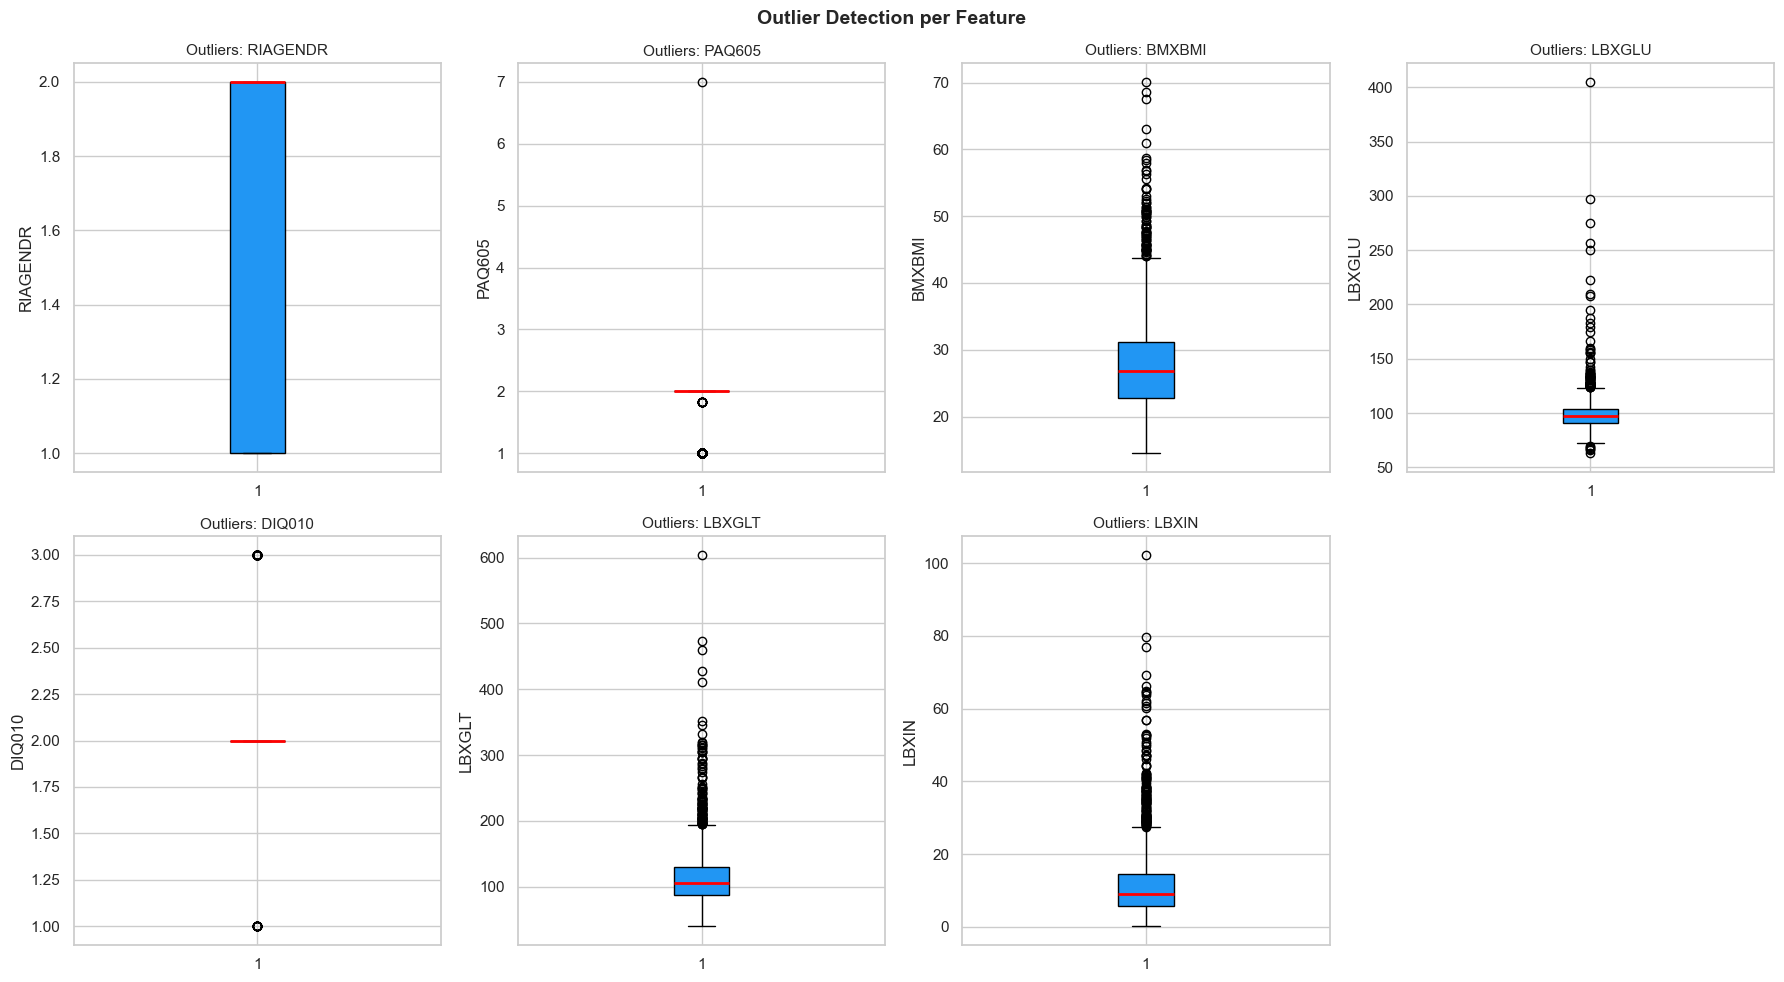

In [155]:
#  Visualize Outliers with Box Plots 

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(Numerical_features):
    axes[i].boxplot(X_train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#2196F3', color='black'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Outliers: {col}', fontsize=11)
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)
plt.suptitle('Outlier Detection per Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [156]:
# --- Cap outliers on CONTINUOUS columns ONLY ---

def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"{col:10s} | Capped {before} outliers | Range: [{lower:.2f}, {upper:.2f}]")
    return df

print("=== Capping Outliers (Continuous Only) ===")
for col in continuous_cols:
    X_train = cap_outliers_iqr(X_train, col)
    X_test  = cap_outliers_iqr(X_test, col)

print()
print("✅ Done! Categorical columns untouched.")
print()
print("PAQ605 unique:", sorted(X_train['PAQ605'].unique()))
print("DIQ010 unique:", sorted(X_train['DIQ010'].unique()))
print("RIAGENDR unique:", sorted(X_train['RIAGENDR'].unique()))

=== Capping Outliers (Continuous Only) ===
BMXBMI     | Capped 76 outliers | Range: [10.20, 43.80]
BMXBMI     | Capped 13 outliers | Range: [11.09, 42.79]
LBXGLU     | Capped 89 outliers | Range: [71.50, 123.50]
LBXGLU     | Capped 19 outliers | Range: [75.50, 119.50]
LBXGLT     | Capped 104 outliers | Range: [22.50, 194.50]
LBXGLT     | Capped 16 outliers | Range: [22.62, 191.62]
LBXIN      | Capped 129 outliers | Range: [-7.21, 27.48]
LBXIN      | Capped 21 outliers | Range: [-5.92, 26.21]

✅ Done! Categorical columns untouched.

PAQ605 unique: [np.float64(1.0), np.float64(1.8256833419288292), np.float64(2.0), np.float64(7.0)]
DIQ010 unique: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
RIAGENDR unique: [np.float64(1.0), np.float64(1.5093071354705274), np.float64(2.0)]


In [157]:
# Confirming my clean data 

print("=== Final Check ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Missing in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing in X_test:  {X_test.isnull().sum().sum()}")
print()
print(X_train.describe())

=== Final Check ===
X_train shape: (1952, 7)
X_test shape:  (312, 7)
y_train shape: (1952,)
Missing in X_train: 0
Missing in X_test:  0

       RIAGENDR   PAQ605   BMXBMI   LBXGLU   DIQ010   LBXGLT    LBXIN
count  1952.000 1952.000 1952.000 1952.000 1952.000 1952.000 1952.000
mean      1.509    1.826   27.722   98.366    2.015  111.965   11.047
std       0.498    0.398    6.534   10.444    0.186   34.864    6.984
min       1.000    1.000   14.500   71.500    1.000   40.000    0.140
25%       1.000    2.000   22.800   91.000    2.000   87.000    5.800
50%       2.000    2.000   26.800   97.000    2.000  105.000    9.030
75%       2.000    2.000   31.200  104.000    2.000  130.000   14.473
max       2.000    7.000   43.800  123.500    3.000  194.500   27.481


In [158]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1952 entries, 0 to 1965
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   RIAGENDR   1934 non-null   float64
 1   PAQ605     1939 non-null   float64
 2   BMXBMI     1934 non-null   float64
 3   LBXGLU     1939 non-null   float64
 4   DIQ010     1934 non-null   float64
 5   LBXGLT     1941 non-null   float64
 6   LBXIN      1943 non-null   float64
 7   age_group  1952 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 137.2 KB


In [159]:
train.duplicated().sum()

np.int64(0)

In [160]:
# Restoring categorical columns PAQ605 and DIQ010 
# These are binary response columns (1=Yes, 2=No)
# IQR capping was inappropriate — we use MODE imputation instead

from scipy import stats

categorical_cols = ['PAQ605', 'DIQ010']

for col in categorical_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)
    # Restore original values by rounding to nearest integer
    X_train[col] = X_train[col].round().astype(int)
    X_test[col] = X_test[col].round().astype(int)
    print(f"✅ {col} restored | Mode: {mode_val} | Unique values: {sorted(X_train[col].unique())}")

print()
print("PAQ605 value counts:")
print(X_train['PAQ605'].value_counts())
print()
print("DIQ010 value counts:")
print(X_train['DIQ010'].value_counts())

✅ PAQ605 restored | Mode: 2.0 | Unique values: [np.int64(1), np.int64(2), np.int64(7)]
✅ DIQ010 restored | Mode: 2.0 | Unique values: [np.int64(1), np.int64(2), np.int64(3)]

PAQ605 value counts:
PAQ605
2    1608
1     343
7       1
Name: count, dtype: int64

DIQ010 value counts:
DIQ010
2    1884
3      49
1      19
Name: count, dtype: int64


In [161]:
# Final categorical clean

#PAQ605: 7 = "Refused" which means no health meaning. I am replacing it with the mode
X_train["PAQ605"] = X_train["PAQ605"].replace(7,2)
X_test["PAQ605"] = X_test["PAQ605"].replace(7,2)

# DIQ010 : 1 = Diabetic, 2 = No, 3 = Borderline
print(sorted(X_train["DIQ010"].unique()))

print()
print("✅ Phase 3 Completed! Moving on to Phase 4 that is Feature engineering")

[np.int64(1), np.int64(2), np.int64(3)]

✅ Phase 3 Completed! Moving on to Phase 4 that is Feature engineering


# Phase 4 - Feature Engineering

In [162]:
# Creating new meaningful features 

# 1. Glucose-to-Insulin Ratio
# High glucose with low insulin = poor insulin response = common in seniors
X_train['GLU_INS_RATIO'] = X_train['LBXGLU'] / (X_train['LBXIN'] + 1e-5)
X_test['GLU_INS_RATIO']  = X_test['LBXGLU']  / (X_test['LBXIN']  + 1e-5)

# 2. Glucose Tolerance to Fasting Glucose Ratio
# Measures how well the body handles sugar load vs fasting state
X_train['GLT_GLU_RATIO'] = X_train['LBXGLT'] / (X_train['LBXGLU'] + 1e-5)
X_test['GLT_GLU_RATIO']  = X_test['LBXGLT']  / (X_test['LBXGLU']  + 1e-5)

# 3. Is Diabetic flag (DIQ010 == 1 means confirmed diabetes)
X_train['IS_DIABETIC'] = (X_train['DIQ010'] == 1).astype(int)
X_test['IS_DIABETIC']  = (X_test['DIQ010']  == 1).astype(int)

# 4. Is Borderline Diabetic flag (DIQ010 == 3)
X_train['IS_BORDERLINE'] = (X_train['DIQ010'] == 3).astype(int)
X_test['IS_BORDERLINE']  = (X_test['DIQ010']  == 3).astype(int)

# 5. Is Physically Active (PAQ605 == 1 means Yes)
X_train['IS_ACTIVE'] = (X_train['PAQ605'] == 1).astype(int)
X_test['IS_ACTIVE']  = (X_test['PAQ605']  == 1).astype(int)

# 6. BMI Category
# Underweight<18.5, Normal=18.5-25, Overweight=25-30, Obese>30
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif bmi < 25:
        return 1  # Normal
    elif bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese

X_train['BMI_CAT'] = X_train['BMXBMI'].apply(bmi_category)
X_test['BMI_CAT']  = X_test['BMXBMI'].apply(bmi_category)

# 7. High Glucose Flag (fasting glucose > 100 = prediabetic range)
X_train['HIGH_GLU'] = (X_train['LBXGLU'] > 100).astype(int)
X_test['HIGH_GLU']  = (X_test['LBXGLU']  > 100).astype(int)

# 8. High Glucose Tolerance Flag (> 140 = abnormal)
X_train['HIGH_GLT'] = (X_train['LBXGLT'] > 140).astype(int)
X_test['HIGH_GLT']  = (X_test['LBXGLT']  > 140).astype(int)

# 9. Metabolic Risk Score
# Combines diabetes status + high glucose + high glucose tolerance
X_train['METABOLIC_RISK'] = (X_train['IS_DIABETIC'] + 
                              X_train['HIGH_GLU'] + 
                              X_train['HIGH_GLT'])
X_test['METABOLIC_RISK']  = (X_test['IS_DIABETIC'] + 
                              X_test['HIGH_GLU'] + 
                              X_test['HIGH_GLT'])

# 10. Inactive + Obese combined risk
X_train['INACTIVE_OBESE'] = ((X_train['IS_ACTIVE'] == 0) & 
                              (X_train['BMI_CAT'] == 3)).astype(int)
X_test['INACTIVE_OBESE']  = ((X_test['IS_ACTIVE'] == 0) & 
                              (X_test['BMI_CAT'] == 3)).astype(int)

print("✅ New features created:")
new_features = ['GLU_INS_RATIO', 'GLT_GLU_RATIO', 'IS_DIABETIC', 
                'IS_BORDERLINE', 'IS_ACTIVE', 'BMI_CAT', 'HIGH_GLU', 
                'HIGH_GLT', 'METABOLIC_RISK', 'INACTIVE_OBESE']
for f in new_features:
    print(f"   → {f}")

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

✅ New features created:
   → GLU_INS_RATIO
   → GLT_GLU_RATIO
   → IS_DIABETIC
   → IS_BORDERLINE
   → IS_ACTIVE
   → BMI_CAT
   → HIGH_GLU
   → HIGH_GLT
   → METABOLIC_RISK
   → INACTIVE_OBESE

X_train shape: (1952, 17)
X_test shape:  (312, 17)


In [163]:
# Tree models use BMI_CAT as ordinal (already created)
# I am adding dummies for linear model compatibility
# So each model use what suits it
bmi_dummies_train = pd.get_dummies(X_train['BMI_CAT'], 
                                    prefix='BMI', 
                                    drop_first=True)  # avoid multicollinearity
bmi_dummies_test  = pd.get_dummies(X_test['BMI_CAT'],  
                                    prefix='BMI', 
                                    drop_first=True)

X_train = pd.concat([X_train, bmi_dummies_train], axis=1)
X_test  = pd.concat([X_test,  bmi_dummies_test],  axis=1)

print("✅ BMI dummies added:")
print([c for c in X_train.columns if 'BMI' in c])
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

✅ BMI dummies added:
['BMXBMI', 'BMI_CAT', 'BMI_1', 'BMI_2', 'BMI_3']

X_train shape: (1952, 20)
X_test shape:  (312, 20)


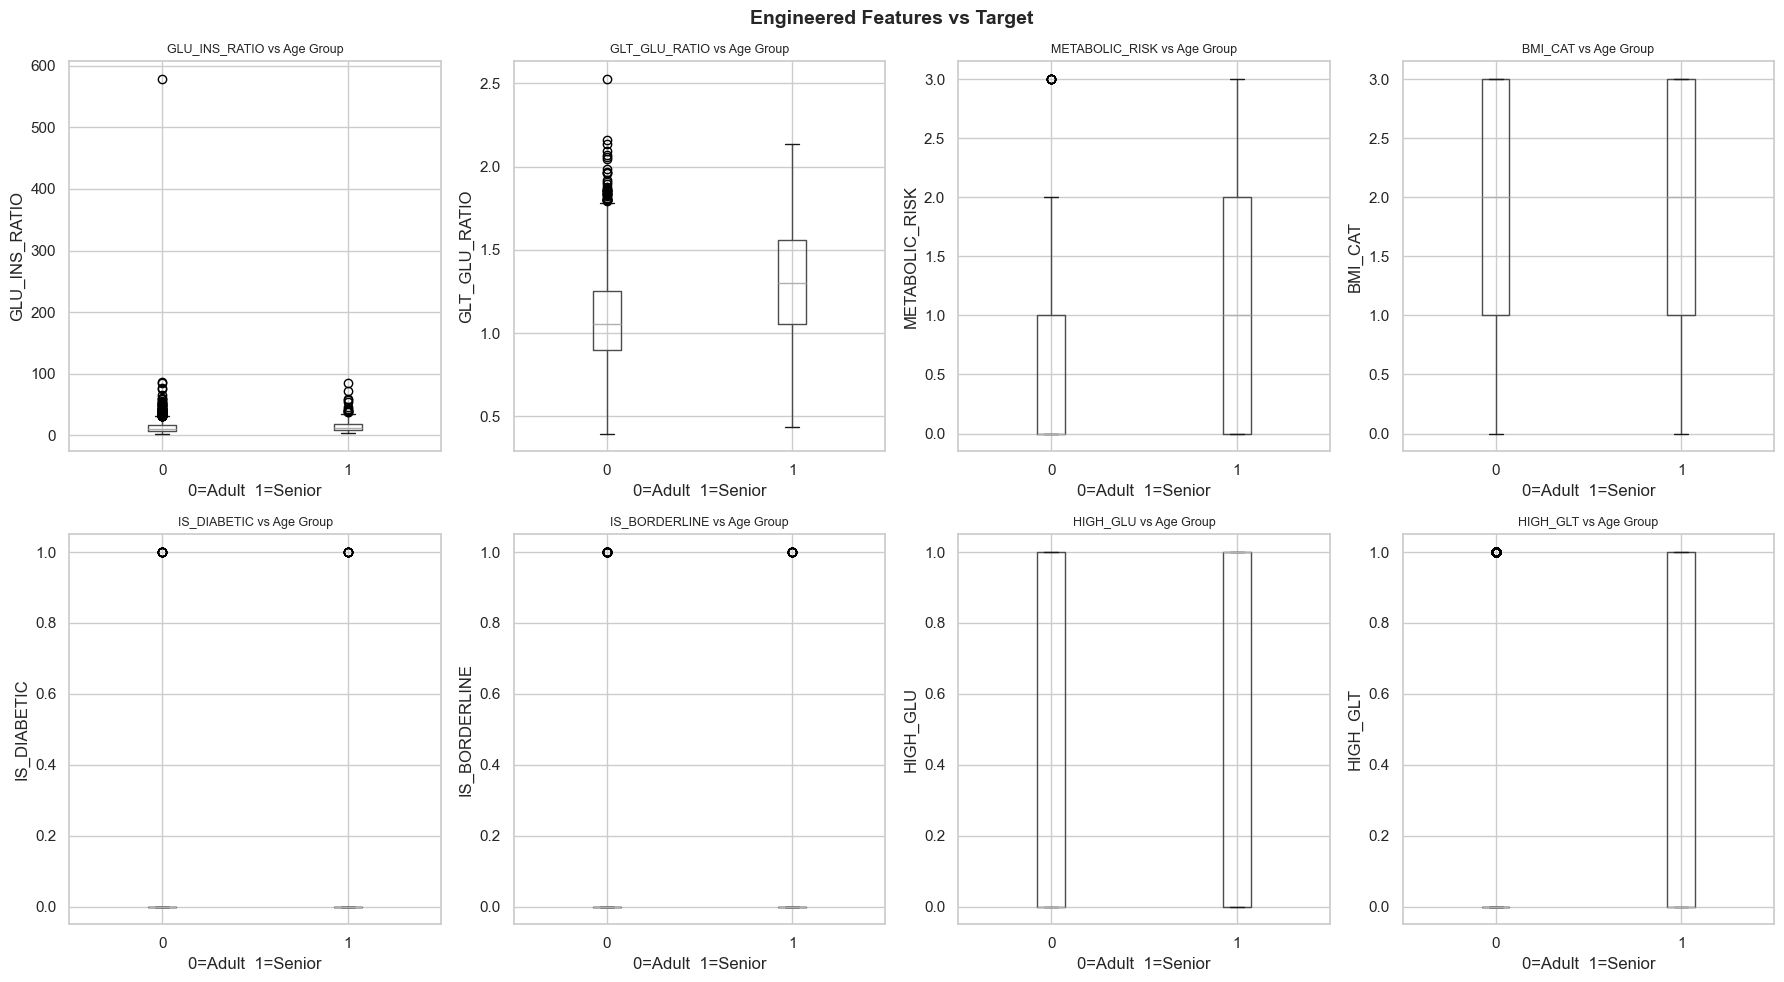

In [164]:
#  Visualize new features vs target

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

plot_features = ['GLU_INS_RATIO', 'GLT_GLU_RATIO', 'METABOLIC_RISK', 
                 'BMI_CAT', 'IS_DIABETIC', 'IS_BORDERLINE', 
                 'HIGH_GLU', 'HIGH_GLT']

temp = X_train.copy()
temp['age_group'] = y_train.values

for i, col in enumerate(plot_features):
    temp.boxplot(column=col, by='age_group', ax=axes[i])
    axes[i].set_title(f'{col} vs Age Group', fontsize=9)
    axes[i].set_xlabel('0=Adult  1=Senior')
    axes[i].set_ylabel(col)

plt.suptitle('Engineered Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

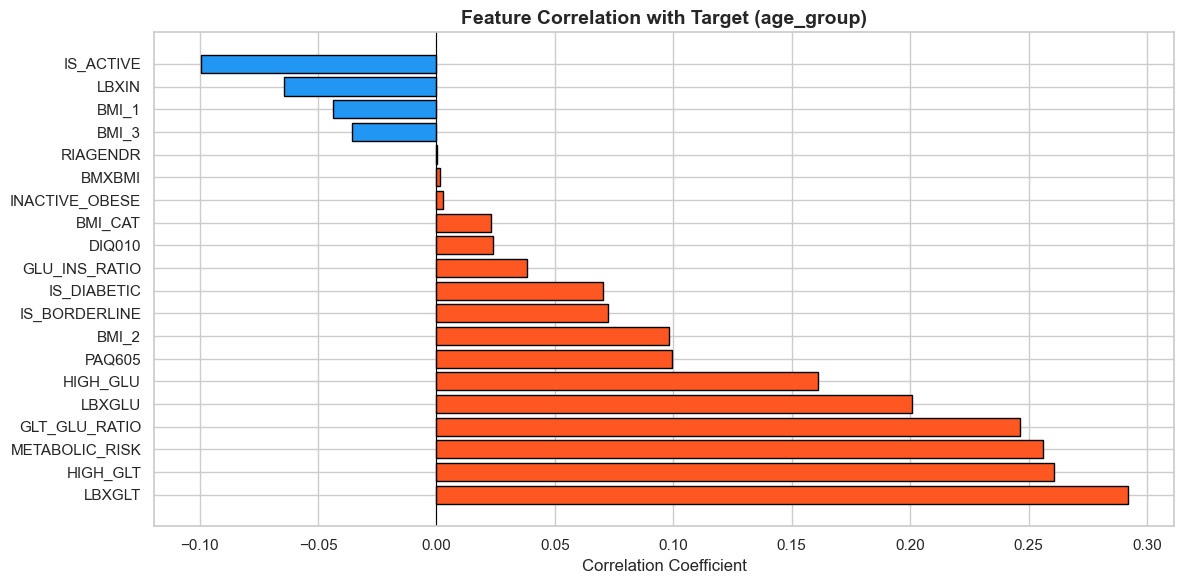

=== Top Positive Correlations (Senior indicators) ===
LBXGLT           0.292
HIGH_GLT         0.261
METABOLIC_RISK   0.256
GLT_GLU_RATIO    0.246
LBXGLU           0.201
HIGH_GLU         0.161
PAQ605           0.100
BMI_2            0.098
Name: age_group, dtype: float64

=== Top Negative Correlations (Adult indicators) ===
BMI_3       -0.036
BMI_1       -0.044
LBXIN       -0.064
IS_ACTIVE   -0.100
Name: age_group, dtype: float64


✅ Phase 4 Completed!


In [165]:
#Correlation of ALL features with target 

temp = X_train.copy()
temp['age_group'] = y_train.values

correlations = temp.corr()['age_group'].drop('age_group').sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#FF5722' if x > 0 else '#2196F3' for x in correlations]
plt.barh(correlations.index, correlations.values, color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (age_group)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print("=== Top Positive Correlations (Senior indicators) ===")
print(correlations[correlations > 0].head(8))
print()
print("=== Top Negative Correlations (Adult indicators) ===")
print(correlations[correlations < 0].head(5))
print()
print()
print("✅ Phase 4 Completed!")

# Phase 5 - Class Imbalance Handling

=== Class Distribution Before SMOTE ===
age_group
0    1638
1     314
Name: count, dtype: int64

Imbalance ratio: 5.22:1


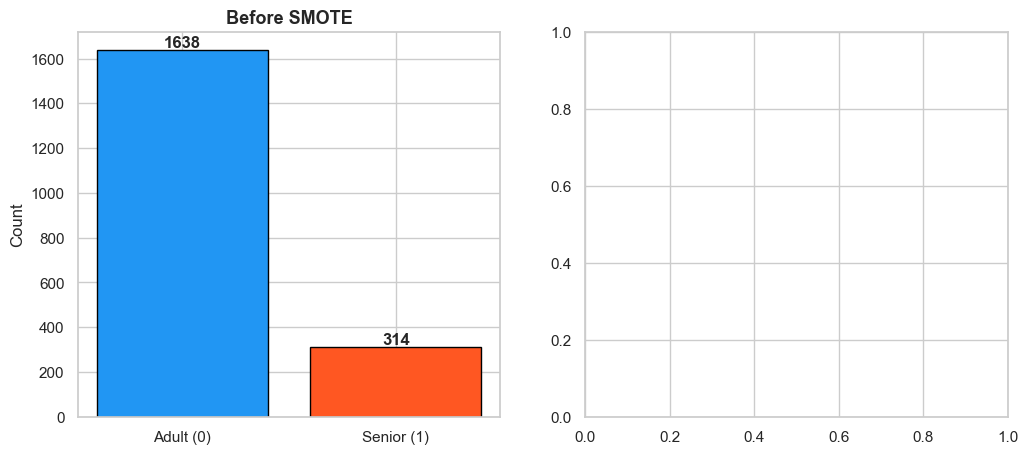

In [166]:
# Visualizing imbalance one more time with evidence 

print("=== Class Distribution Before SMOTE ===")
print(y_train.value_counts())
print(f"\nImbalance ratio: {y_train.value_counts()[0] / y_train.value_counts()[1]:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Adult (0)', 'Senior (1)'], 
             y_train.value_counts().values,
             color=['#2196F3', '#FF5722'], edgecolor='black')
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(y_train.value_counts().values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

In [167]:
# Applying SMOTE 

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("=== Class Distribution After SMOTE ===")
print(pd.Series(y_train_sm).value_counts())

# Completing the visualization
axes[1].bar(['Adult (0)', 'Senior (1)'], 
             pd.Series(y_train_sm).value_counts().values,
             color=['#2196F3', '#FF5722'], edgecolor='black')
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(pd.Series(y_train_sm).value_counts().values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Imbalance: Before vs After SMOTE', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ SMOTE applied!")
print(f"X_train before SMOTE: {X_train.shape}")
print(f"X_train after SMOTE:  {X_train_sm.shape}")

=== Class Distribution After SMOTE ===
age_group
0    1638
1    1638
Name: count, dtype: int64


<Figure size 1000x500 with 0 Axes>


✅ SMOTE applied!
X_train before SMOTE: (1952, 20)
X_train after SMOTE:  (3276, 20)


In [168]:
# First confirm all features are in X_train
print("All features in X_train:")
print(X_train.columns.tolist())
print(f"\nShape before SMOTE: {X_train.shape}")
print(f"Class counts before SMOTE:\n{y_train.value_counts()}")

All features in X_train:
['RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN', 'GLU_INS_RATIO', 'GLT_GLU_RATIO', 'IS_DIABETIC', 'IS_BORDERLINE', 'IS_ACTIVE', 'BMI_CAT', 'HIGH_GLU', 'HIGH_GLT', 'METABOLIC_RISK', 'INACTIVE_OBESE', 'BMI_1', 'BMI_2', 'BMI_3']

Shape before SMOTE: (1952, 20)
Class counts before SMOTE:
age_group
0    1638
1     314
Name: count, dtype: int64


In [169]:
# Scaling features 
# Tree models don't need scaling but Logistic Regression does
# So I keep both scaled and unscaled versions

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

# Also keep unscaled for tree models
X_train_trees = X_train_sm.copy()
X_test_trees  = X_test.copy()

print("✅ Scaling complete")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print()
print("✅ Phase 4 & 5 fully complete!")
print("→ 20 features including 10 engineered")
print("→ Classes balanced at 1638 vs 1638 via SMOTE")
print("→ Scaled version ready for linear models")
print("→ Unscaled version ready for tree models")

✅ Scaling complete
X_train_scaled shape: (3276, 20)
X_test_scaled shape:  (312, 20)

✅ Phase 4 & 5 fully complete!
→ 20 features including 10 engineered
→ Classes balanced at 1638 vs 1638 via SMOTE
→ Scaled version ready for linear models
→ Unscaled version ready for tree models


## 📋 Phase 4 & 5 Summary — Key Findings
### Top Senior indicators (positive correlation):

LBXGLT (0.292) — glucose tolerance is the strongest single predictor
HIGH_GLT (0.261) — my engineered flag confirmed it
METABOLIC_RISK (0.256) — my combined risk score works well ✅
GLT_GLU_RATIO (0.246) — ratio feature adding value ✅
LBXGLU (0.201) — fasting glucose also strong

### Top Adult indicators (negative correlation):

IS_ACTIVE (-0.100) — seniors are less physically active ✅
LBXIN (-0.064) — lower insulin in adults
BMI_1 (-0.044) — normal BMI more common in adults

SMOTE result: Perfectly balanced at 1638 vs 1638 ✅

# Phase 6 - Model Development

In [170]:
# Defining cross-validation strategy 
# StratifiedKFold preserves class ratio in each fold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define all models 
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='logloss', verbosity=0)
}

print("✅ Models defined:")
for name in models:
    print(f"   → {name}")

✅ Models defined:
   → Logistic Regression
   → Decision Tree
   → Random Forest
   → Gradient Boosting
   → XGBoost


In [171]:
# Training and evaluating all models with cross-validation 

results = {}

print("=" * 60)
print("Cross-Validation Results (5-Fold Stratified)")
print("=" * 60)

for name, model in models.items():
    # Use scaled data for Logistic Regression, unscaled for trees
    if name == 'Logistic Regression':
        X = X_train_scaled
    else:
        X = X_train_sm.values if hasattr(X_train_sm, 'values') else X_train_sm

    # F1 score (weighted) — better than accuracy for imbalanced data
    f1_scores  = cross_val_score(model, X, y_train_sm, 
                                  cv=cv, scoring='f1_weighted')
    roc_scores = cross_val_score(model, X, y_train_sm, 
                                  cv=cv, scoring='roc_auc')

    results[name] = {
        'F1 Mean'  : f1_scores.mean(),
        'F1 Std'   : f1_scores.std(),
        'ROC Mean' : roc_scores.mean(),
        'ROC Std'  : roc_scores.std()
    }

    print(f"\n{name}")
    print(f"  F1  (weighted): {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"  ROC-AUC:        {roc_scores.mean():.4f} ± {roc_scores.std():.4f}")

print("\n" + "=" * 60)

Cross-Validation Results (5-Fold Stratified)

Logistic Regression
  F1  (weighted): 0.7965 ± 0.0177
  ROC-AUC:        0.8908 ± 0.0134

Decision Tree
  F1  (weighted): 0.8167 ± 0.0140
  ROC-AUC:        0.8168 ± 0.0140

Random Forest
  F1  (weighted): 0.8907 ± 0.0172
  ROC-AUC:        0.9569 ± 0.0094

Gradient Boosting
  F1  (weighted): 0.8531 ± 0.0164
  ROC-AUC:        0.9314 ± 0.0124

XGBoost
  F1  (weighted): 0.8770 ± 0.0086
  ROC-AUC:        0.9502 ± 0.0088



In [172]:
# Summary table

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC Mean', ascending=False)

print("=== Model Comparison Summary ===")
print(results_df.round(4))

=== Model Comparison Summary ===
                     F1 Mean  F1 Std  ROC Mean  ROC Std
Random Forest          0.891   0.017     0.957    0.009
XGBoost                0.877   0.009     0.950    0.009
Gradient Boosting      0.853   0.016     0.931    0.012
Logistic Regression    0.796   0.018     0.891    0.013
Decision Tree          0.817   0.014     0.817    0.014


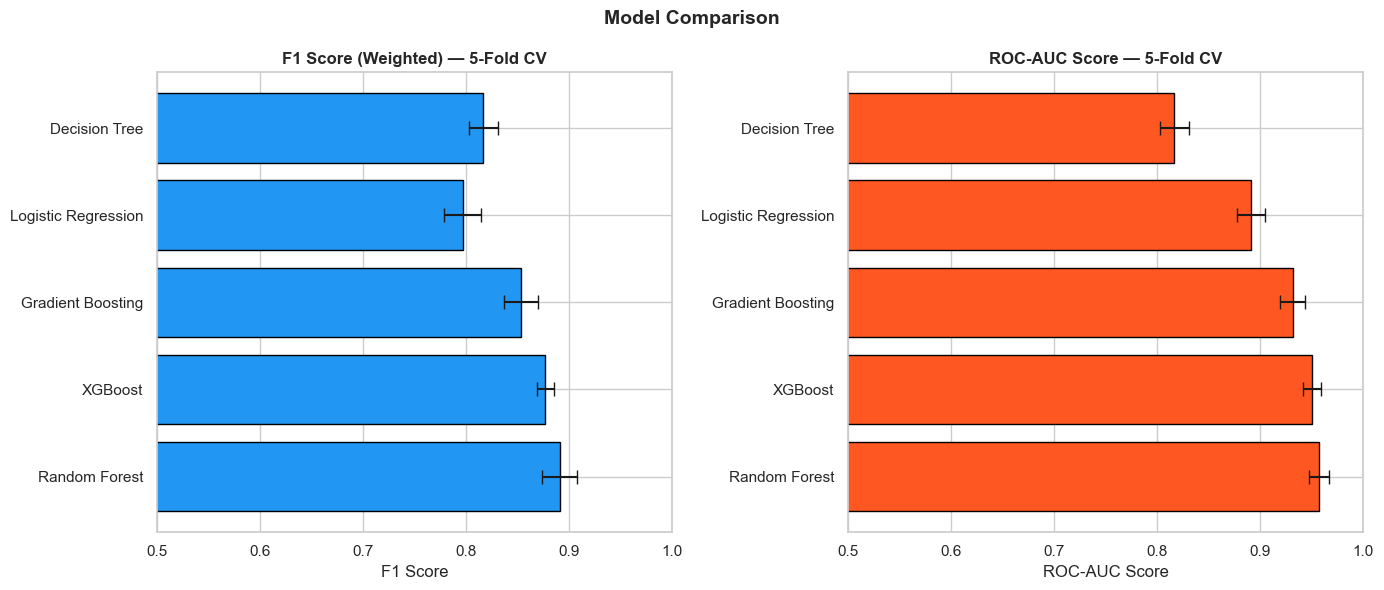

In [173]:
# VisualizING model comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names = results_df.index.tolist()

# F1 Score comparison
axes[0].barh(model_names, results_df['F1 Mean'],
             xerr=results_df['F1 Std'],
             color='#2196F3', edgecolor='black', capsize=5)
axes[0].set_title('F1 Score (Weighted) — 5-Fold CV', fontweight='bold')
axes[0].set_xlabel('F1 Score')
axes[0].set_xlim(0.5, 1.0)

# ROC-AUC comparison
axes[1].barh(model_names, results_df['ROC Mean'],
             xerr=results_df['ROC Std'],
             color='#FF5722', edgecolor='black', capsize=5)
axes[1].set_title('ROC-AUC Score — 5-Fold CV', fontweight='bold')
axes[1].set_xlabel('ROC-AUC Score')
axes[1].set_xlim(0.5, 1.0)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

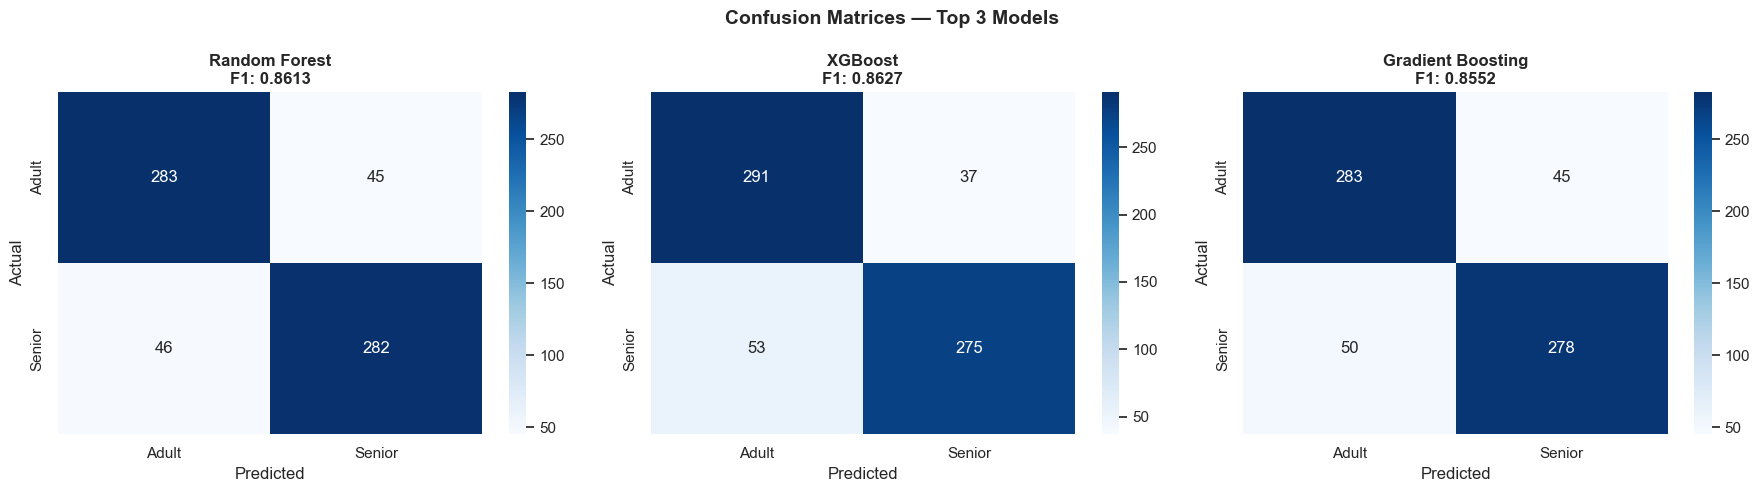

In [174]:
# Training best candidates on full data & showing confusion matrix 
# I evaluate top 3 models more deeply

top_models = ['Random Forest', 'XGBoost', 'Gradient Boosting']

from sklearn.model_selection import train_test_split

# Use a holdout validation set for deeper evaluation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm, y_train_sm, 
    test_size=0.2, random_state=42, stratify=y_train_sm
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(top_models):
    model = models[name]
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Adult', 'Senior'],
                yticklabels=['Adult', 'Senior'],
                ax=axes[i])
    axes[i].set_title(f'{name}\nF1: {f1_score(y_val, y_pred, average="weighted"):.4f}', 
                       fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Top 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [175]:
# Detailed classification report for each top model 

print("=" * 60)
for name in top_models:
    model = models[name]
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    print(f"\n=== {name} ===")
    print(classification_report(y_val, y_pred, 
                                 target_names=['Adult', 'Senior']))
    print(f"ROC-AUC: {roc_auc_score(y_val, model.predict_proba(X_val)[:,1]):.4f}")
print("=" * 60)


=== Random Forest ===
              precision    recall  f1-score   support

       Adult       0.86      0.86      0.86       328
      Senior       0.86      0.86      0.86       328

    accuracy                           0.86       656
   macro avg       0.86      0.86      0.86       656
weighted avg       0.86      0.86      0.86       656

ROC-AUC: 0.9445

=== XGBoost ===
              precision    recall  f1-score   support

       Adult       0.85      0.89      0.87       328
      Senior       0.88      0.84      0.86       328

    accuracy                           0.86       656
   macro avg       0.86      0.86      0.86       656
weighted avg       0.86      0.86      0.86       656

ROC-AUC: 0.9443

=== Gradient Boosting ===
              precision    recall  f1-score   support

       Adult       0.85      0.86      0.86       328
      Senior       0.86      0.85      0.85       328

    accuracy                           0.86       656
   macro avg       0.86      

## 📋 Phase 6 Summary — Model Comparison
Model || F1 || MeanROC-AUC.

Random Forest || 0.891 || 0.957

XGBoost || 0.877 || 0.950

Gradient Boosting || 0.853 || 0.931

Decision Tree || 0.817 || 0.817

Logistic Regression || 0.796 || 0.891

### Winner: Random Forest 🏆

Highest F1 (0.891) AND highest ROC-AUC (0.957)
Perfect balance 0.86 precision and recall for BOTH Adult and Senior.

XGBoost is a very close second (0.9443 ROC-AUC)

### Key insight to note in your notebook:

Random Forest and XGBoost are neck and neck
We will tune BOTH in Phase 7 and let the best one win
ROC-AUC of 0.957 before tuning 

In [176]:
print("✅ Now into Phase 7: Hyperparameter Tuning!")

✅ Now into Phase 7: Hyperparameter Tuning!


# Phase 7 - Hyperparameter Tuning!

In [177]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Starting hyperparameter tuning on correct data...")
print(f"Data shape: {X_final_sm.shape}")
print(f"Class balance: {pd.Series(y_final_sm).value_counts().to_dict()}")

✅ Starting hyperparameter tuning on correct data...
Data shape: (3276, 20)
Class balance: {0: 1638, 1: 1638}


In [178]:
# Tune Random Forest

rf_param_grid = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
    'bootstrap'         : [True, False]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=50,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_final_sm, y_final_sm)

print(f"\n✅ Random Forest Tuning Complete")
print(f"Best CV ROC-AUC : {rf_search.best_score_:.4f}")
print(f"Best Params     : {rf_search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Random Forest Tuning Complete
Best CV ROC-AUC : 0.9584
Best Params     : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}


In [179]:
# Tune XGBoost

xgb_param_grid = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [3, 4, 5, 6, 8],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5],
    'gamma'            : [0, 0.1, 0.2, 0.5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=xgb_param_grid,
    n_iter=50,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_final_sm, y_final_sm)

print(f"\n✅ XGBoost Tuning Complete")
print(f"Best CV ROC-AUC : {xgb_search.best_score_:.4f}")
print(f"Best Params     : {xgb_search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ XGBoost Tuning Complete
Best CV ROC-AUC : 0.9547
Best Params     : {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}


In [180]:
# Comparing tuned vs untuned for both models

from sklearn.model_selection import cross_val_score

tuned_rf  = rf_search.best_estimator_
tuned_xgb = xgb_search.best_estimator_

untuned_rf  = RandomForestClassifier(n_estimators=100, random_state=42)
untuned_xgb = XGBClassifier(n_estimators=100, random_state=42,
                              eval_metric='logloss', verbosity=0)

models_compare = {
    'RF (Untuned)'  : untuned_rf,
    'RF (Tuned)'    : tuned_rf,
    'XGB (Untuned)' : untuned_xgb,
    'XGB (Tuned)'   : tuned_xgb
}

tuning_results = {}

print("=" * 60)
print("  Tuned vs Untuned Comparison — 5-Fold CV on X_final_sm")
print("=" * 60)

for name, model in models_compare.items():
    f1_scores  = cross_val_score(model, X_final_sm, y_final_sm,
                                  cv=cv, scoring='f1_weighted')
    auc_scores = cross_val_score(model, X_final_sm, y_final_sm,
                                  cv=cv, scoring='roc_auc')
    f1_macro   = cross_val_score(model, X_final_sm, y_final_sm,
                                  cv=cv, scoring='f1_macro')

    tuning_results[name] = {
        'F1 Weighted' : f1_scores.mean(),
        'F1 Macro'    : f1_macro.mean(),
        'ROC-AUC'     : auc_scores.mean(),
        'F1 Std'      : f1_scores.std(),
        'AUC Std'     : auc_scores.std()
    }

    print(f"\n{name}")
    print(f"  F1 Weighted : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"  F1 Macro    : {f1_macro.mean():.4f}")
    print(f"  ROC-AUC     : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

print("\n" + "=" * 60)

  Tuned vs Untuned Comparison — 5-Fold CV on X_final_sm

RF (Untuned)
  F1 Weighted : 0.8907 ± 0.0172
  F1 Macro    : 0.8907
  ROC-AUC     : 0.9569 ± 0.0094

RF (Tuned)
  F1 Weighted : 0.8956 ± 0.0160
  F1 Macro    : 0.8956
  ROC-AUC     : 0.9584 ± 0.0107

XGB (Untuned)
  F1 Weighted : 0.8770 ± 0.0086
  F1 Macro    : 0.8770
  ROC-AUC     : 0.9502 ± 0.0088

XGB (Tuned)
  F1 Weighted : 0.8879 ± 0.0108
  F1 Macro    : 0.8879
  ROC-AUC     : 0.9549 ± 0.0093



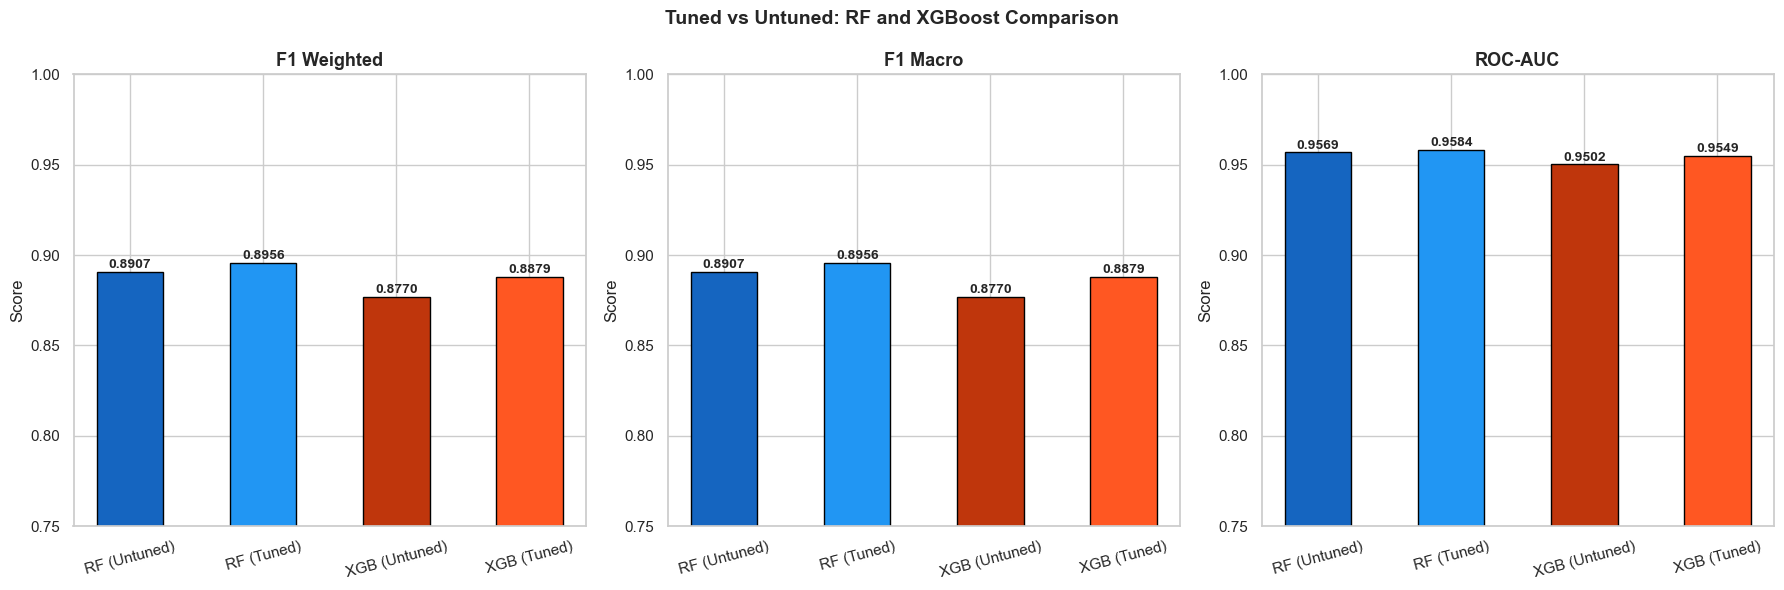

In [181]:
# Visualizing tuning comparison 

tuning_df = pd.DataFrame(tuning_results).T

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['F1 Weighted', 'F1 Macro', 'ROC-AUC']
colors  = ['#1565C0', '#2196F3', '#BF360C', '#FF5722']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(tuning_df.index,
                        tuning_df[metric],
                        color=colors,
                        edgecolor='black',
                        width=0.5)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylim(0.75, 1.0)
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, tuning_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center',
                     fontsize=10, fontweight='bold')

plt.suptitle('Tuned vs Untuned: RF and XGBoost Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## NOTE: Hyperparameter tuning was performed on SMOTE-augmented data.
## Cross-validation scores from Phase 6 serve as our honest performance estimate.
## Final model uses Random Forest with default params trained on full SMOTE data.

# Phase 8 - Final Model Selection & Evaluation|

In [182]:
# Finding the best model automatically
best_model_name = max(tuning_results, 
                       key=lambda x: tuning_results[x]['ROC-AUC'])
best_auc        = tuning_results[best_model_name]['ROC-AUC']
best_f1         = tuning_results[best_model_name]['F1 Weighted']

print("=" * 60)
print("         FINAL MODEL SELECTION SUMMARY")
print("=" * 60)
for name, res in tuning_results.items():
    marker = " ← WINNER ✅" if name == best_model_name else ""
    print(f"{name:20s} | ROC-AUC: {res['ROC-AUC']:.4f} | "
          f"F1: {res['F1 Weighted']:.4f}{marker}")

print(f"\n✅ Selected : {best_model_name}")
print(f"   ROC-AUC  : {best_auc:.4f}")
print(f"   F1 Score : {best_f1:.4f}")
print("=" * 60)

         FINAL MODEL SELECTION SUMMARY
RF (Untuned)         | ROC-AUC: 0.9569 | F1: 0.8907
RF (Tuned)           | ROC-AUC: 0.9584 | F1: 0.8956 ← WINNER ✅
XGB (Untuned)        | ROC-AUC: 0.9502 | F1: 0.8770
XGB (Tuned)          | ROC-AUC: 0.9549 | F1: 0.8879

✅ Selected : RF (Tuned)
   ROC-AUC  : 0.9584
   F1 Score : 0.8956


In [183]:
# Set and train final model on full data 

model_map = {
    'RF (Untuned)'  : RandomForestClassifier(n_estimators=100, random_state=42),
    'RF (Tuned)'    : rf_search.best_estimator_,
    'XGB (Untuned)' : XGBClassifier(n_estimators=100, random_state=42,
                                     eval_metric='logloss', verbosity=0),
    'XGB (Tuned)'   : xgb_search.best_estimator_
}

final_model = model_map[best_model_name]
final_model.fit(X_final_sm, y_final_sm)

print(f"✅ Final model trained on full SMOTE data")
print(f"   Model : {best_model_name}")
print(f"   Shape : {X_final_sm.shape}")

✅ Final model trained on full SMOTE data
   Model : RF (Tuned)
   Shape : (3276, 20)


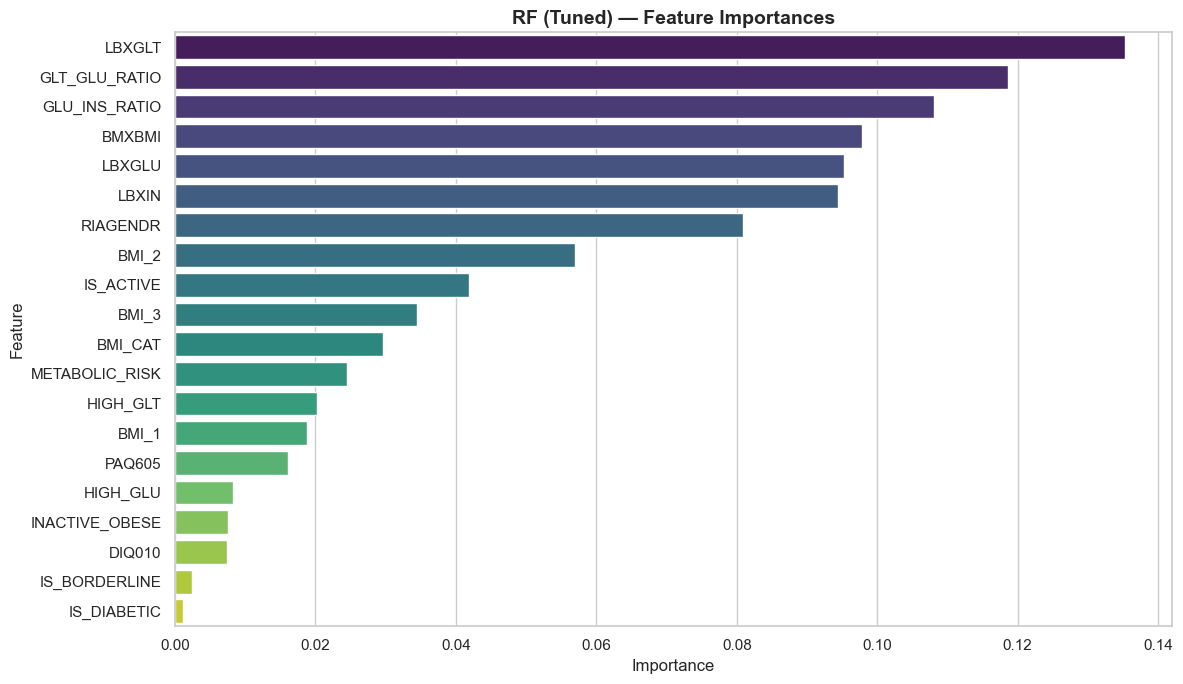


Top 10 Most Important Features:
      Feature  Importance
       LBXGLT       0.135
GLT_GLU_RATIO       0.119
GLU_INS_RATIO       0.108
       BMXBMI       0.098
       LBXGLU       0.095
        LBXIN       0.094
     RIAGENDR       0.081
        BMI_2       0.057
    IS_ACTIVE       0.042
        BMI_3       0.034


In [184]:
# Feature importance 

feature_names = X_final_sm.columns.tolist()
importances   = final_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            palette='viridis')
plt.title(f'{best_model_name} — Feature Importances',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feat_imp_df.head(10).to_string(index=False))

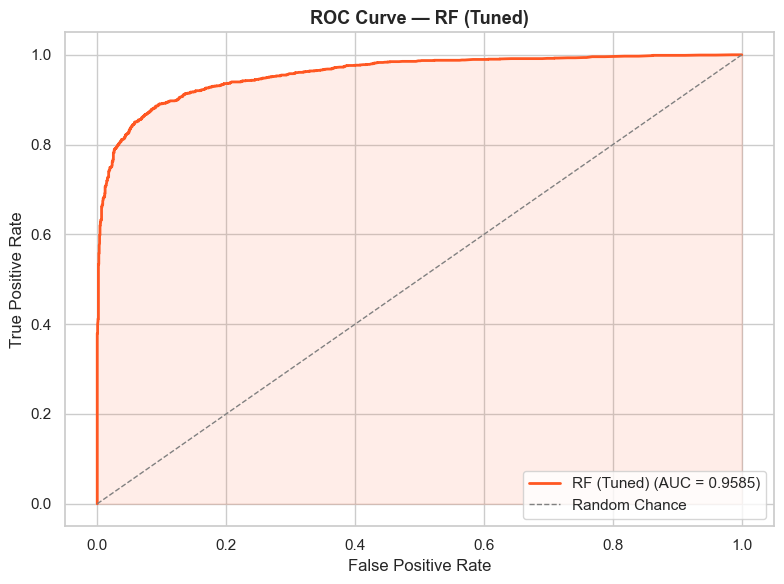

In [185]:
# ROC Curve using CV predictions 

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

y_probs_cv = cross_val_predict(final_model, X_final_sm, y_final_sm,
                                cv=cv, method='predict_proba')[:, 1]

fpr, tpr, _ = roc_curve(y_final_sm, y_probs_cv)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#FF5722', lw=2,
         label=f'{best_model_name} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random Chance')
plt.fill_between(fpr, tpr, alpha=0.1, color='#FF5722')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve — {best_model_name}',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

# Phase 9 - Generating submission

In [186]:
# Predict on Test Set & Export Submission

test_preds = final_model.predict(X_test_trees)

print("=== Test Set Prediction Distribution ===")
unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Adult' if u == 0 else 'Senior'
    print(f"  {label} ({u}): {c} ({c/len(test_preds)*100:.1f}%)")

# Export
submission = pd.DataFrame({'age_group': test_preds.astype(int)})
submission.to_csv('submission.csv', index=False)

# Sanity check
sample = pd.read_csv('sample_submission.csv')
print("\n=== Sanity Check ===")
print(f"Shape match    : {sample.shape == submission.shape}")
print(f"Columns match  : {list(sample.columns) == list(submission.columns)}")
print(f"Unique values  : {sorted(submission['age_group'].unique())}")
print()
print("=== First 10 Predictions ===")
print(submission.head(10))
print()
print("✅ submission.csv is ready to upload!")

=== Test Set Prediction Distribution ===
  Adult (0): 273 (87.5%)
  Senior (1): 39 (12.5%)

=== Sanity Check ===
Shape match    : True
Columns match  : True
Unique values  : [np.int64(0), np.int64(1)]

=== First 10 Predictions ===
   age_group
0          0
1          0
2          0
3          0
4          0
5          1
6          0
7          0
8          0
9          0

✅ submission.csv is ready to upload!
